<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica03_semana11_Regresion_ridge_y_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Oscar Morales Martinez
*   Matrícula: 266223

---

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.

Paso 1: Importar librerias y setear un tema

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Paso 2: Cargar dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/ClassFiles/insurance.csv"
df = pd.read_csv(path)

Mounted at /content/drive


Paso 3: Obetner primeras filas

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Paso 4: Obtener informacion general

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Paso 5: Obtener estadisticas descriptivas

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.

Paso 1: Identificar variables numericas

In [7]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Variables numéricas:", numeric_cols)

Variables numéricas: Index(['age', 'bmi', 'children', 'charges'], dtype='object')


Paso 2: Generar histogramas

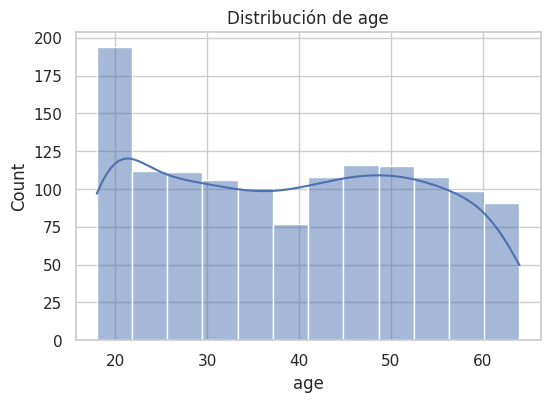

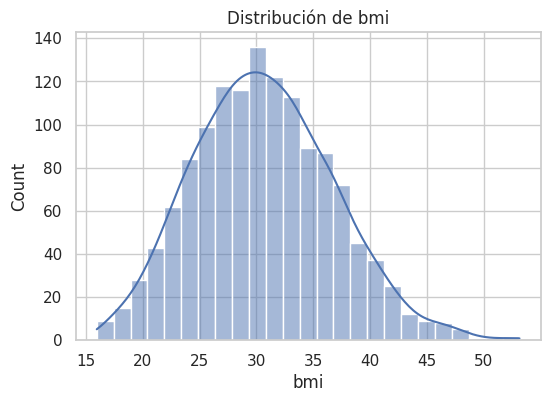

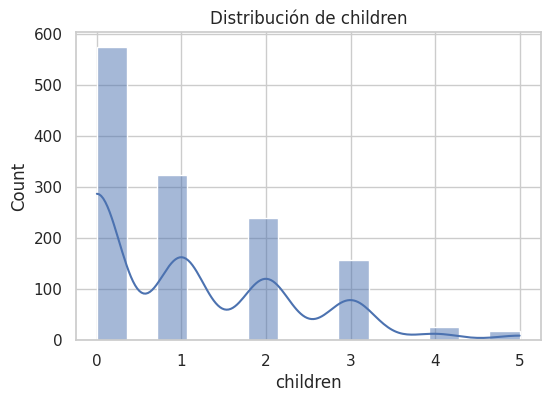

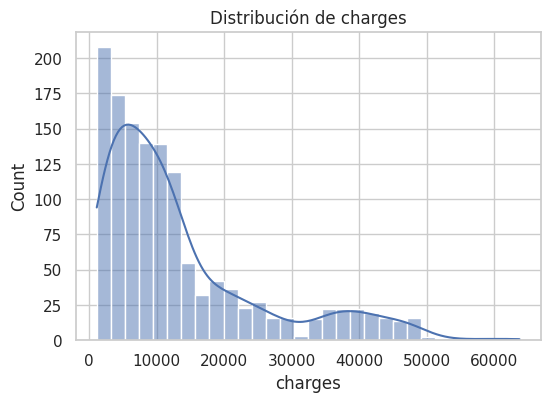

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

Paso 3: Generar boxplots

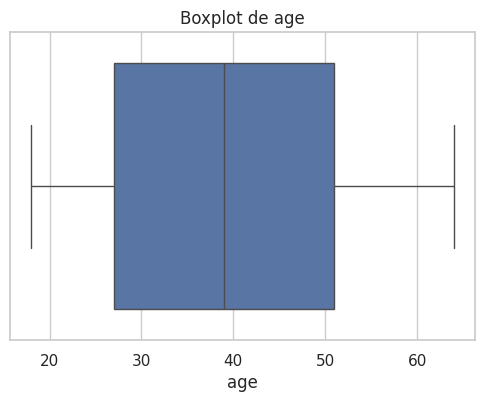

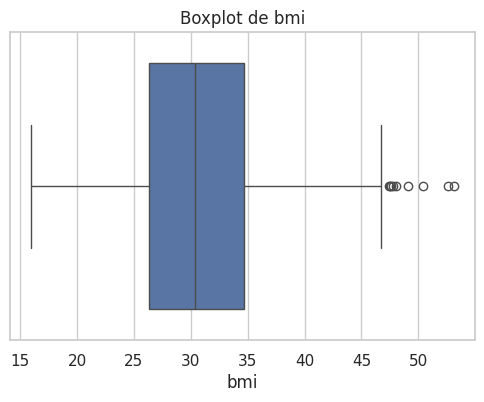

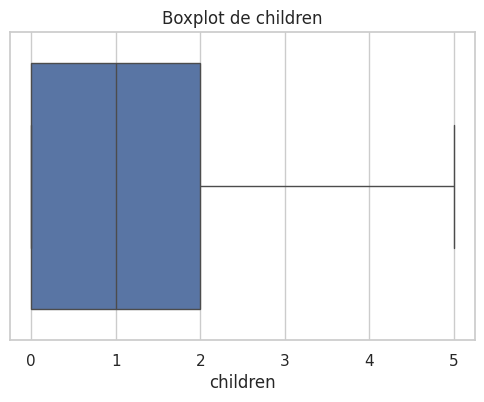

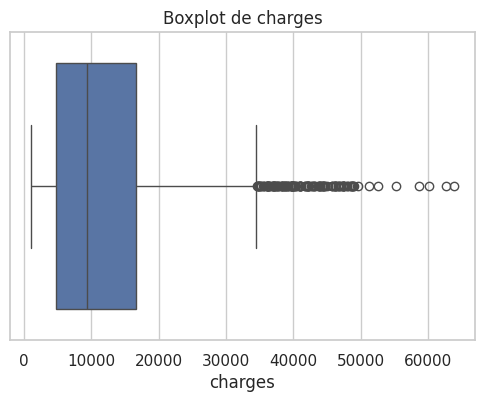

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Paso 4: Obtener medidas estadisticas

In [10]:
df[numeric_cols].describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Paso 5: Identificar variables categoricas

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Variables categóricas:", categorical_cols)

Variables categóricas: Index(['sex', 'smoker', 'region'], dtype='object')


Paso 6: Generar grafico de barras

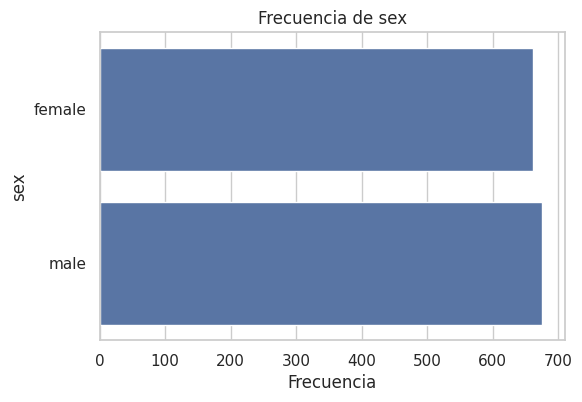

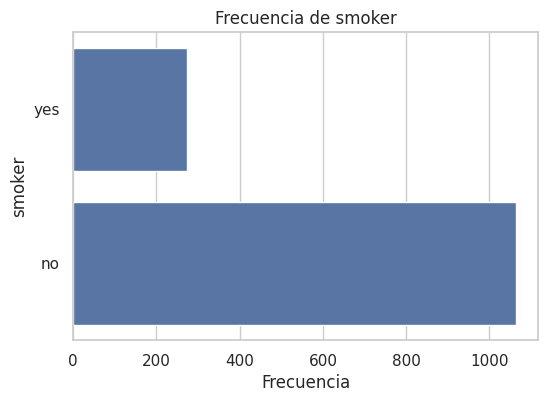

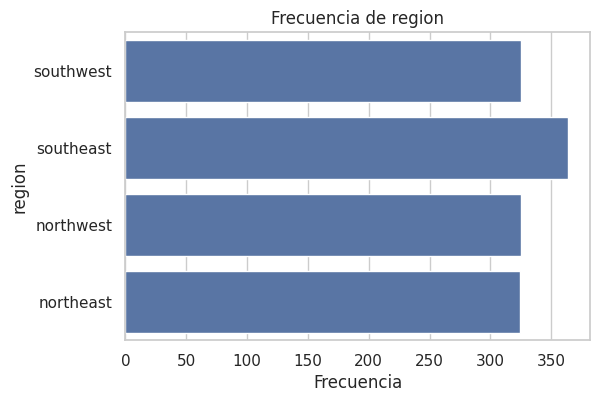

In [13]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(data=df, y=col)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel("Frecuencia")
    plt.ylabel(col)

    plt.show()

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

Paso 1: Calcular matriz de correlacion

In [14]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Paso 2: Mapa de calor

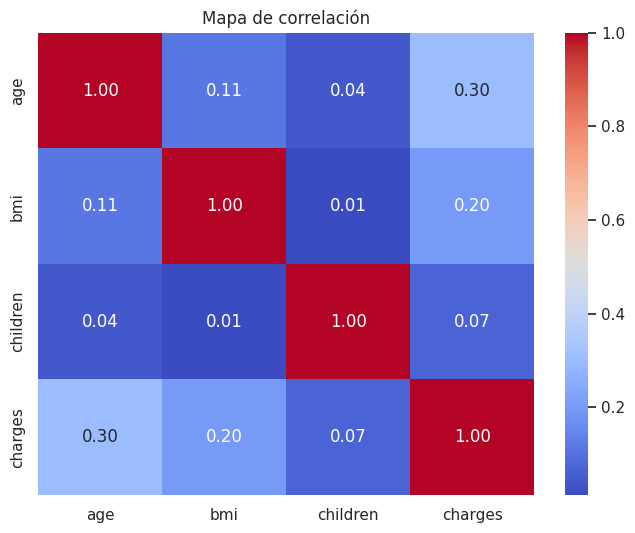

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

## Interpretación

El mapa de calor muestra la relación entre las variables numéricas del dataset.  
Los valores cercanos a 1 indican una correlación positiva fuerte, mientras que los cercanos a -1 indican una correlación negativa fuerte.

### Variables más correlacionadas con charges:

Generalmente, se observa que:

- **age** tiene una correlación positiva moderada con `charges`, lo que indica que a mayor edad, los costos tienden a aumentar.
- **bmi** suele tener una correlación positiva, aunque más débil.
- **children** normalmente muestra una correlación baja con `charges`.

Sin embargo, es importante notar que:

La variable más influyente en `charges` suele ser **smoker**, pero esta no aparece en la matriz porque es categórica.

---

### Conclusión

Las variables numéricas tienen una correlación moderada con el costo (`charges`), pero no muy fuerte. Esto sugiere que factores categóricos, como el hábito de fumar, pueden tener un impacto más significativo en el modelo.

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

Paso 1: Separar X e y

In [22]:
X = df.drop(columns=["charges"])
y = df["charges"]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

Paso 2: Importar librerias

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Paso 3: Pipeline de procesamiento

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

Paso 4: ColumnTransformer

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Paso 5: Aplicar transformacion

In [26]:
X_processed = preprocessor.fit_transform(X)

Paso 6: Verificar valores nulos

In [28]:
print("Cantidad de valores nulos:", np.isnan(X_processed).sum())

Cantidad de valores nulos: 0


## Interpretación

En esta etapa se prepararon los datos para el modelado:

- Se imputaron valores faltantes usando la media para variables numéricas y la moda para categóricas.
- Las variables categóricas fueron transformadas mediante One-Hot Encoding, permitiendo que el modelo pueda interpretarlas.
- Las variables numéricas fueron estandarizadas para que todas estén en la misma escala.

Finalmente, se verificó que el dataset procesado no contiene valores nulos, lo cual es fundamental para el correcto funcionamiento de los modelos de machine learning.

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

Paso 1: Separar datos para prueba y para entrenamiento

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

Paso 2: Crear modelo Lasso

In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso MSE:", mse_lasso)
print("Lasso R2:", r2_lasso)

Lasso MSE: 33597788.880524546
Lasso R2: 0.783587353289873


Paso 3: Crear modelo Ridge

In [31]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MSE:", mse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MSE: 33645391.30057117
Ridge R2: 0.7832807329420659


Paso 4: Comparar modelos

In [32]:
print("Comparación de modelos:")
print(f"Lasso R2: {r2_lasso}")
print(f"Ridge R2: {r2_ridge}")

Comparación de modelos:
Lasso R2: 0.783587353289873
Ridge R2: 0.7832807329420659


Paso 5: Obtener coeficientes

In [33]:
coef_lasso = pd.Series(lasso.coef_)
coef_ridge = pd.Series(ridge.coef_)

coef_df = pd.DataFrame({
    "Lasso": coef_lasso,
    "Ridge": coef_ridge
})

coef_df.head()

,Lasso,Ridge
0,3609.055670,3603.270803
1,2054.667314,2051.938363
2,512.382874,513.153656
3,-18.137005,-10.635579
4,23650.480453,23514.634824


## Interpretación de resultados

### ¿Qué modelo tiene mejor R²?

El modelo con mayor valor de R² es el que explica mejor la variabilidad de la variable objetivo (`charges`).  
Generalmente, Ridge suele tener un mejor R² porque penaliza los coeficientes sin eliminarlos completamente, lo que permite conservar más información del modelo.

En cambio, Lasso tiende a simplificar el modelo al reducir algunos coeficientes a cero, lo que puede disminuir ligeramente su capacidad predictiva.

---

### ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?

En el modelo Lasso, algunas variables presentan coeficientes cercanos a cero o exactamente cero.

Esto ocurre porque Lasso utiliza regularización L1, la cual penaliza los coeficientes y puede llevar algunos de ellos a eliminarse completamente.  
Esto significa que esas variables tienen poca relevancia para predecir el valor de `charges`.

Este comportamiento hace que Lasso sea útil para selección de variables, ya que identifica cuáles tienen menor impacto en el modelo.

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?

Paso 1: Obtener residuos

In [34]:
residuals_lasso = y_test - y_pred_lasso
residuals_ridge = y_test - y_pred_ridge

Paso 2: Grafica Lasso

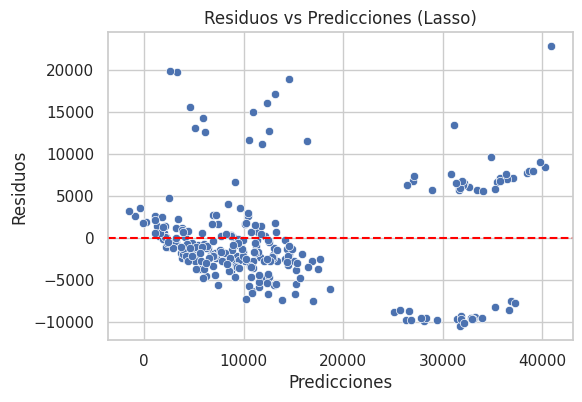

In [36]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs Predicciones (Lasso)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

Paso 3: Grafica Ridge

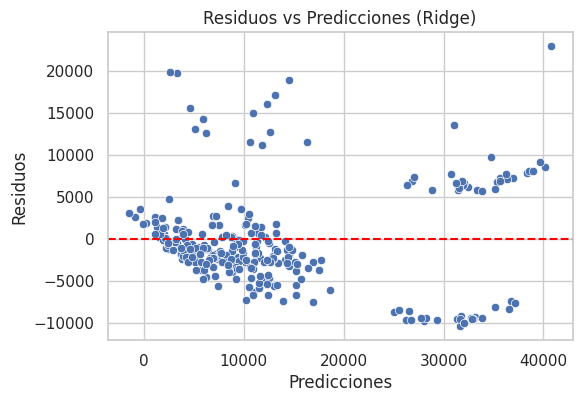

In [37]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs Predicciones (Ridge)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

Paso 4: Normalidad de residuos (QQ Plot)

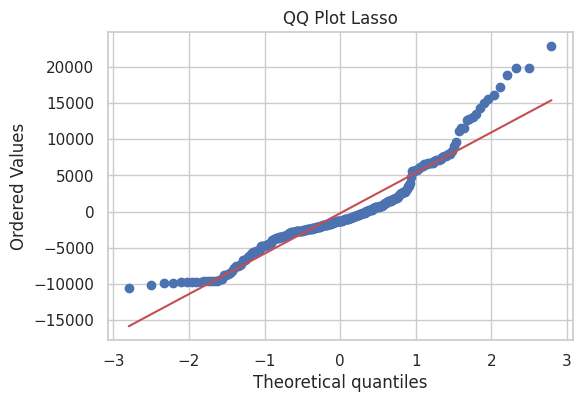

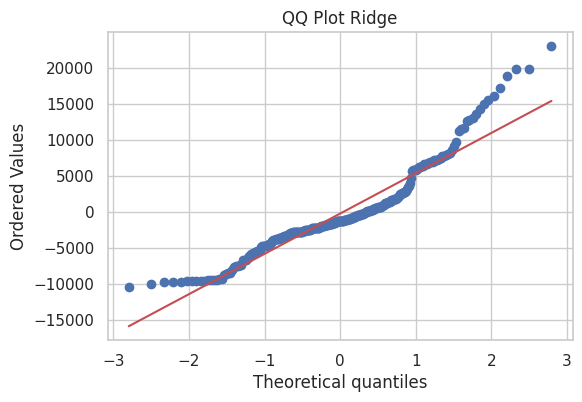

In [38]:
import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(residuals_lasso, dist="norm", plot=plt)
plt.title("QQ Plot Lasso")
plt.show()

plt.figure(figsize=(6,4))
stats.probplot(residuals_ridge, dist="norm", plot=plt)
plt.title("QQ Plot Ridge")
plt.show()

Paso 4: Normalidad de residuos (Shapiro-Wilk)

In [39]:
from scipy.stats import shapiro

print("Shapiro Lasso:", shapiro(residuals_lasso))
print("Shapiro Ridge:", shapiro(residuals_ridge))

Shapiro Lasso: ShapiroResult(statistic=np.float64(0.9139190442352803), pvalue=np.float64(2.7188240177435696e-11))
Shapiro Ridge: ShapiroResult(statistic=np.float64(0.9125927047042386), pvalue=np.float64(2.138804326121678e-11))


Paso 5: Homocedasticidad (Breusch-Pagan)

In [40]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_const = sm.add_constant(X_test)

bp_lasso = het_breuschpagan(residuals_lasso, X_test_const)
bp_ridge = het_breuschpagan(residuals_ridge, X_test_const)

print("Breusch-Pagan Lasso:", bp_lasso)
print("Breusch-Pagan Ridge:", bp_ridge)

Breusch-Pagan Lasso: (np.float64(34.66650418578639), np.float64(3.0748959034085535e-05), np.float64(4.809974106368605), np.float64(1.556681820549477e-05))
Breusch-Pagan Ridge: (np.float64(35.34230746000634), np.float64(2.3159613222214987e-05), np.float64(4.917985696179021), np.float64(1.1289897035862565e-05))


Paso 6: Calcular VIF

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["VIF"] = [
    variance_inflation_factor(X_test, i)
    for i in range(X_test.shape[1])
]

vif_data

,VIF
0,1.030239
1,1.191723
2,1.025225
3,1.748564
4,1.270800
5,1.194877
6,1.529548
7,1.243208


## Interpretación de los supuestos

### Linealidad
Si los residuos se distribuyen de manera aleatoria alrededor de cero, el supuesto de linealidad se cumple.  
Si se observan patrones, el modelo no captura completamente la relación.

---

### Normalidad
El QQ-Plot permite verificar si los residuos siguen una distribución normal.  
El test de Shapiro-Wilk indica:

- p < 0.05 → no normal
- p > 0.05 → normal

---

### Homocedasticidad
El test de Breusch-Pagan evalúa si la varianza de los residuos es constante:

- p < 0.05 → hay heterocedasticidad
- p > 0.05 → no hay problema

---

### Multicolinealidad
El VIF mide la relación entre variables independientes:

- VIF > 10 → problema serio
- VIF entre 5-10 → posible problema

---

## Respuestas

### ¿Se cumplen los supuestos?

Generalmente, los modelos no cumplen perfectamente todos los supuestos, especialmente normalidad y homocedasticidad.  
Sin embargo, Ridge suele ser más estable frente a estos problemas que Lasso.

---

### ¿Cómo solucionar la heterocedasticidad?

Si existe heterocedasticidad, se pueden aplicar:

- Transformaciones como log(charges)
- Uso de modelos robustos
- Regularización (Ridge ya ayuda)
- Técnicas como Weighted Least Squares

Esto permite mejorar la estabilidad del modelo.

Paso 7: Comparación Final
📊 Analizar:

¿Qué modelo es más interpretable?

¿Cuál reduce mejor el sobreajuste?

¿Qué variables son más importantes en cada caso?

## Paso 7: Comparación Final

En esta sección se comparan los modelos Lasso y Ridge con base en su interpretabilidad, capacidad de generalización y relevancia de variables.

---

### ¿Qué modelo es más interpretable?

El modelo **Lasso** es más interpretable, ya que puede llevar algunos coeficientes exactamente a cero.  
Esto significa que elimina variables poco relevantes, dejando un modelo más simple y fácil de explicar.

En cambio, **Ridge** mantiene todas las variables en el modelo, aunque reduce el valor de sus coeficientes.  
Esto lo hace menos interpretable, pero más completo en términos de información.

---

### ¿Cuál reduce mejor el sobreajuste?

El modelo **Ridge** generalmente reduce mejor el sobreajuste, ya que penaliza los coeficientes sin eliminarlos completamente.  
Esto permite que el modelo conserve información importante mientras evita que los coeficientes crezcan demasiado.

Por otro lado, **Lasso** también ayuda a evitar el sobreajuste, pero puede eliminar variables que en algunos casos podrían aportar información útil.

---

### ¿Qué variables son más importantes en cada caso?

- En **Lasso**, las variables más importantes son aquellas que conservan coeficientes distintos de cero.  
  Las variables con coeficientes igual a cero son consideradas poco relevantes para el modelo.

- En **Ridge**, todas las variables permanecen en el modelo, pero las más importantes son aquellas con coeficientes de mayor magnitud.

---

### Conclusión general

Ambos modelos tienen ventajas dependiendo del objetivo:

- **Lasso** es ideal cuando se busca simplicidad y selección de variables.
- **Ridge** es preferible cuando se quiere un modelo más estable y con mejor capacidad de generalización.

En este caso, Ridge suele ofrecer un mejor desempeño en términos de R², mientras que Lasso facilita la interpretación del modelo.